# Flight Delay Analysis
**Dataset:** 2015 US domestic flights (~5.8M rows)  
**Goal:** Predict arrival/departure delays

## 1. Setup & Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR = Path('..')

## 2. Data Loading

In [15]:
# Explicit dtypes cut memory usage roughly in half
FLIGHT_DTYPES = {
    # 'YEAR': 'int16', # alles 2015 -> raus
    
    'MONTH': 'int8', 
    'DAY': 'int8', 
    'DAY_OF_WEEK': 'int8',

    'AIRLINE': 'string',

    'FLIGHT_NUMBER': 'int32', 
    
    # 'TAIL_NUMBER' viele missing, irrelevant -> raus
    'ORIGIN_AIRPORT': 'string',
    'DESTINATION_AIRPORT': 'string',

    'SCHEDULED_DEPARTURE': 'string',  
    'DEPARTURE_TIME': 'string', # 1% missing -> raus
    'DEPARTURE_DELAY': 'float32', # 1% missing = DEPARTURE_TIME

    #'TAXI_OUT': 'float32', # 2% viele missing -> raus
    #'WHEELS_OFF': 'string', # 2% viele missing = TAXI_OFF

    'SCHEDULED_TIME': 'float32', # 6 mising
    'ELAPSED_TIME': 'float32', # 2% viele missing
    #'AIR_TIME': 'float32', # 2% viele missing = ELAPSED
    'DISTANCE': 'int32',
    
    #'WHEELS_ON': 'string',  # # 2% viele missing -> raus
    #'TAXI_ON': 'float32', # 2% viele missing = WHEELS_ON

    'SCHEDULED_ARRIVAL' : 'string', 
    'ARRIVAL_TIME': 'string',
    'ARRIVAL_DELAY': 'float32', 

    #'DIVERTED': 'bool', # alle 0 -> raus
    #'CANCELLED': 'bool', # 99.99% sind 0 -> raus

    #'AIRSYSTEM_DELAY'    _> raus
    #'SECURITY_DELAY'     _> raus
    #'AIRLINE_DELAY'      _> raus
    #'LATEAIRCRAFT_DELAY' _> raus
    #'WEATHER_DELAY'      _> raus
}

print('Loading flights.csv (~592 MB) ...')
flights = pd.read_csv(DATA_DIR / 'flights.csv', dtype=FLIGHT_DTYPES)
airlines = pd.read_csv(DATA_DIR / 'airlines.csv')
airports = pd.read_csv(DATA_DIR / 'airports.csv')

# Keep only columns defined in FLIGHT_DTYPES
flights = flights[list(FLIGHT_DTYPES.keys())]
before = len(flights)

# Drop rows with any missing value
flights = flights.dropna()
after = len(flights)

print(f'dropped {before-after} rows...')
print(f'flights: {flights.shape[0]:,} rows × {flights.shape[1]} cols')

Loading flights.csv (~592 MB) ...
dropped 105071 rows...
flights: 5,714,008 rows × 16 cols


## 2a. Datenbereinigung

In [16]:
valid_airlines = set(airlines['IATA_CODE'])
before = len(flights)
invalid_airlines = flights.loc[~flights['AIRLINE'].isin(valid_airlines), 'AIRLINE'].value_counts()
flights = flights[flights['AIRLINE'].isin(valid_airlines)]
print(f'Airline-Filter: {before - len(flights):,} Zeilen entfernt → {len(flights):,} verbleibend')
print('\nEntfernte Airline IATA-Codes:')
print(invalid_airlines.to_string() if len(invalid_airlines) else '  keine')

Airline-Filter: 0 Zeilen entfernt → 5,714,008 verbleibend

Entfernte Airline IATA-Codes:
  keine


In [17]:
valid_airports = set(airports['IATA_CODE'])
before = len(flights)
invalid_origins = flights.loc[~flights['ORIGIN_AIRPORT'].isin(valid_airports), 'ORIGIN_AIRPORT'].value_counts()
invalid_dests = flights.loc[~flights['DESTINATION_AIRPORT'].isin(valid_airports), 'DESTINATION_AIRPORT'].value_counts()
flights = flights[
    flights['ORIGIN_AIRPORT'].isin(valid_airports) &
    flights['DESTINATION_AIRPORT'].isin(valid_airports)
]
print(f'Airport-Filter: {before - len(flights):,} Zeilen entfernt → {len(flights):,} verbleibend')
print('\nEntfernte ORIGIN_AIRPORT-Codes:')
print(invalid_origins.to_string() if len(invalid_origins) else '  keine')
print('\nEntfernte DESTINATION_AIRPORT-Codes:')
print(invalid_dests.to_string() if len(invalid_dests) else '  keine')

Airport-Filter: 482,878 Zeilen entfernt → 5,231,130 verbleibend

Entfernte ORIGIN_AIRPORT-Codes:
ORIGIN_AIRPORT
10397    32509
13930    27566
11298    20586
11292    18077
12892    17628
14771    14094
12266    13091
14107    12884
12889    12649
13487    10552
14747    10361
10721    10091
11433     9882
11057     9537
11618     9508
13204     9006
14869     8738
12953     8447
12478     8255
10821     7991
13232     7598
11278     6759
14679     6184
14100     6065
13303     5929
11259     5873
11697     5753
15304     5125
12191     4681
14057     4539
10693     4450
15016     4295
13796     3994
10423     3871
12173     3761
13495     3646
14893     3598
13198     3536
14908     3524
14831     3457
11042     3202
14492     2984
12264     2979
13342     2631
14683     2594
12339     2361
11066     2178
14122     2122
11193     1903
14843     1858
13830     1814
10140     1805
14635     1756
10800     1753
13891     1734
14027     1734
10529     1705
12451     1701
14524     1628
138

In [18]:
out_path = DATA_DIR / 'flights_cut.csv'
flights.to_csv(out_path, index=False)
print(f'Saved {flights.shape[0]:,} rows × {flights.shape[1]} cols → {out_path}')

Saved 5,231,130 rows × 16 cols → ../flights_cut.csv


## 2b. Train / Validation Split

In [19]:
SPLIT_DTYPES = {
    'MONTH': 'int8', 'DAY': 'int8', 'DAY_OF_WEEK': 'int8',
    'AIRLINE': 'string', 'FLIGHT_NUMBER': 'int32',
    'ORIGIN_AIRPORT': 'string', 'DESTINATION_AIRPORT': 'string',
    'SCHEDULED_DEPARTURE': 'string', 'DEPARTURE_TIME': 'string',
    'DEPARTURE_DELAY': 'float32', 'SCHEDULED_TIME': 'float32',
    'ELAPSED_TIME': 'float32', 'DISTANCE': 'int32',
    'SCHEDULED_ARRIVAL': 'string', 'ARRIVAL_TIME': 'string',
    'ARRIVAL_DELAY': 'float32',
}

train = pd.read_csv(DATA_DIR / 'flights_train.csv', dtype=SPLIT_DTYPES)
val   = pd.read_csv(DATA_DIR / 'flights_val.csv',   dtype=SPLIT_DTYPES)
test  = pd.read_csv(DATA_DIR / 'flights_test.csv',  dtype=SPLIT_DTYPES)

total = len(train) + len(val) + len(test)
print(f'Train: {len(train):,} ({len(train)/total:.0%}) | '
      f'Val:  {len(val):,} ({len(val)/total:.0%}) | '
      f'Test: {len(test):,} ({len(test)/total:.0%})')
train.head(5)

Train: 3,138,678 (60%) | Val:  1,046,226 (20%) | Test: 1,046,226 (20%)


,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_TIME,ELAPSED_TIME,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,IS_DELAYED
0,5,5,2,DL,2121,ANC,SEA,1747,1801,14.0,193.0,193.0,1448,2200,2214,14.0,0
1,8,17,1,WN,1687,LAS,HOU,0535,0530,-5.0,180.0,178.0,1235,1035,1028,-7.0,0
2,2,21,6,DL,1353,ATL,PNS,1100,1054,-6.0,77.0,79.0,271,1117,1113,-4.0,0
3,8,12,3,WN,736,HOU,MSY,1910,1922,12.0,60.0,59.0,302,2010,2021,11.0,0
4,12,6,7,OO,6488,MSP,IAH,1045,1048,3.0,173.0,165.0,1034,1338,1333,-5.0,0


In [20]:
train = train.sample(frac=0.2, random_state=42).reset_index(drop=True)
print(f'Train (20% subsample): {len(train):,} rows')

Train (20% subsample): 627,736 rows


## 3. Feature Engineering

In [21]:
# Encoder-Maps nur aus Trainingsdaten (kein Datenleck)
airline_codes = sorted(train['AIRLINE'].unique())
airport_codes = sorted(
    set(train['ORIGIN_AIRPORT'].unique()) | set(train['DESTINATION_AIRPORT'].unique())
)
airline_map = {c: i for i, c in enumerate(airline_codes)}
airport_map = {c: i for i, c in enumerate(airport_codes)}

dist_lookup = (
    train.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])['DISTANCE']
    .median().to_dict()
)
dist_mean = train['DISTANCE'].mean()

def build_features(df):
    f = df.copy()
    f['AIRLINE_ENC'] = f['AIRLINE'].map(airline_map).fillna(-1).astype('int16')
    f['ORIGIN_ENC']  = f['ORIGIN_AIRPORT'].map(airport_map).fillna(-1).astype('int16')
    f['DEST_ENC']    = f['DESTINATION_AIRPORT'].map(airport_map).fillna(-1).astype('int16')
    f['HOUR']        = f['SCHEDULED_DEPARTURE'].str.zfill(4).str[:2].astype('int8')
    return f

REG_FEATURES = ['HOUR', 'MONTH', 'DAY_OF_WEEK', 'AIRLINE_ENC', 'ORIGIN_ENC', 'DEST_ENC', 'DISTANCE']

feat_train = build_features(train)
feat_val   = build_features(val)
feat_test  = build_features(test)

X_train, y_train = feat_train[REG_FEATURES].values, feat_train['ARRIVAL_DELAY'].values
X_val,   y_val   = feat_val[REG_FEATURES].values,   feat_val['ARRIVAL_DELAY'].values
X_test,  y_test  = feat_test[REG_FEATURES].values,  feat_test['ARRIVAL_DELAY'].values

print(f'Features:  {REG_FEATURES}')
print(f'X_train:   {X_train.shape}')
print(f'X_val:     {X_val.shape}')
print(f'X_test:    {X_test.shape}')

Features:  ['HOUR', 'MONTH', 'DAY_OF_WEEK', 'AIRLINE_ENC', 'ORIGIN_ENC', 'DEST_ENC', 'DISTANCE']
X_train:   (627736, 7)
X_val:     (1046226, 7)
X_test:    (1046226, 7)


## 4. Modell-Training (Regression)

In [ ]:
import time
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def scale_pipe(model):
    return Pipeline([('scaler', StandardScaler()), ('model', model)])

x_g_model = HistGradientBoostingRegressor(random_state=42)

# RandomForest mit max_samples=300_000 (subsampled für Geschwindigkeit)
MODELS = [
    ('Linear Regression',     scale_pipe(LinearRegression(n_jobs=-1))),
    ('Ridge (α=1)',           scale_pipe(Ridge(alpha=1.0))),
    ('Lasso (α=0.1)',         scale_pipe(Lasso(alpha=0.1, max_iter=2000))),
    ('ElasticNet (α=0.1)',    scale_pipe(ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=2000))),
    ('RandomForest (sub)',    RandomForestRegressor(
                                  n_estimators=100, n_jobs=-1, random_state=42,
                                  max_samples=300_000, bootstrap=True)),
    ('HistGradientBoosting',  x_g_model),
]

results = []
trained_models = {}

for name, model in MODELS:
    print(f'Training {name}...', end=' ', flush=True)
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    preds_val = model.predict(X_val)
    mae  = mean_absolute_error(y_val, preds_val)
    rms  = rmse(y_val, preds_val)
    results.append({
        'Modell':      name,
        'MAE (Val)':   round(mae, 2),
        'RMSE (Val)':  round(rms, 2),
        'Zeit (s)':    round(elapsed, 1),
    })
    trained_models[name] = model
    print(f'MAE={mae:.1f}  RMSE={rms:.1f}  [{elapsed:.0f}s]')

Training Linear Regression... MAE=21.4  RMSE=39.5  [0s]
Training Ridge (α=1)... MAE=21.4  RMSE=39.5  [0s]
Training Lasso (α=0.1)... MAE=21.4  RMSE=39.5  [0s]
Training ElasticNet (α=0.1)... MAE=21.4  RMSE=39.5  [0s]
Training RandomForest (sub)... 

In [ ]:
results_df = pd.DataFrame(results).set_index('Modell').sort_values('MAE (Val)')
print('\n=== Vergleich auf Validierungsdaten ===')
print(results_df.to_string())


=== Vergleich auf Validierungsdaten ===
                      MAE (Val)  RMSE (Val)  Zeit (s)
Modell                                               
HistGradientBoosting      20.89       38.90     158.0
ElasticNet (α=0.1)        21.38       39.49       0.2
Lasso (α=0.1)             21.38       39.49       0.3
Ridge (α=1)               21.39       39.49       0.1
Linear Regression         21.39       39.49       0.1
RandomForest (sub)        22.63       40.68      10.9


### Visualisierung: MAE & RMSE Vergleich

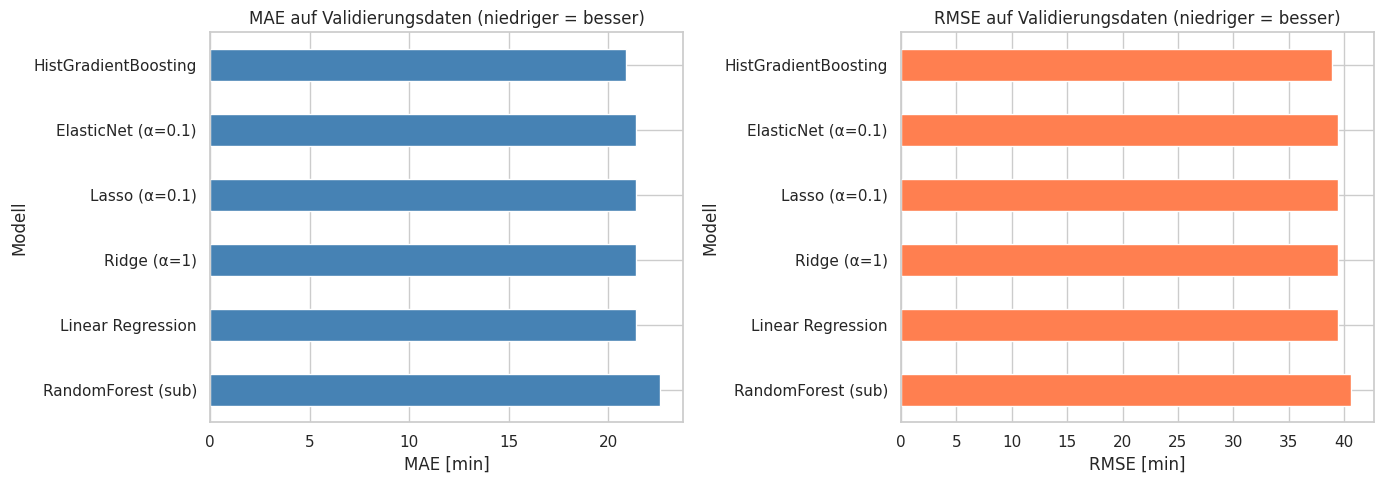

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df[['MAE (Val)']].plot.barh(ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('MAE auf Validierungsdaten (niedriger = besser)')
axes[0].set_xlabel('MAE [min]')
axes[0].invert_yaxis()

results_df[['RMSE (Val)']].plot.barh(ax=axes[1], legend=False, color='coral')
axes[1].set_title('RMSE auf Validierungsdaten (niedriger = besser)')
axes[1].set_xlabel('RMSE [min]')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Vorhersage-Funktion

In [ ]:
from datetime import datetime

def predict_delay(date: str, time: str, origin: str, dest: str, airline: str) -> float:
    """
    date:    'YYYY-MM-DD'
    time:    'HHMM'  z.B. '0830'
    origin / dest / airline: IATA-Codes
    Gibt vorhergesagte Ankunftsverspätung in Minuten zurück.
    """
    dt   = datetime.strptime(date, '%Y-%m-%d')
    hour = int(time[:2])
    dist = dist_lookup.get((origin, dest), dist_lookup.get((dest, origin), dist_mean))

    row = np.array([[
        hour,
        dt.month,
        dt.weekday(),
        airline_map.get(airline, -1),
        airport_map.get(origin, -1),
        airport_map.get(dest, -1),
        dist,
    ]])
    return round(float(x_g_model.predict(row)[0]), 1)

examples = [
    ('2015-07-04', '0800', 'LAX', 'JFK', 'AA'),
    ('2015-12-24', '1800', 'ORD', 'ATL', 'WN'),
    ('2015-03-15', '1200', 'SFO', 'SEA', 'AS'),
]
for args in examples:
    delay = predict_delay(*args)
    label = f'+{delay} min (verspätet)' if delay > 0 else f'{delay} min (pünktlich)'
    print(f'{args[4]}  {args[2]}→{args[3]}  {args[0]} {args[1]}  →  {label}')

AA  LAX→JFK  2015-07-04 0800  →  -4.4 min (pünktlich)
WN  ORD→ATL  2015-12-24 1800  →  +18.3 min (verspätet)
AS  SFO→SEA  2015-03-15 1200  →  +2.0 min (verspätet)
